---
title: "2D Simulation of MT and ZTEM Data"
authors:
  - id: devincowan
---

```{admonition} Introductory notebook
:class: hint
This tutorial teaches basic functionality within SimPEG and is a good entry point for new users.
```

```{admonition} Light-weight notebook
:class: hint
This tutorial requires minimal computational resources and can be executed quickly in the background while other computer processes are running.
```

**Keywords:** NSEM, forward simulation, 2D simulation.

</br>

**Summary:** In this tutorial, we present the fundamentals of simulating 2D NSEM data in SimPEG. We use the module [simpeg.electromagnetics.natural_source](xref:simpeg#simpeg.electromagnetics.natural_source) to simulate ground magnetotelluric and airborne tipper data.

**Learning Objectives:**

- The simulation of 2D NSEM data with SimPEG.
- The data convention SimPEG uses for NSEM data.
- Simulating data resulting from incoming planewaves polarized along the x and y directions.

## Import Modules

Here, we import all of the functionality required to run the notebook for the tutorial exercise. All of the functionality specific to NSEM is imported from [simpeg.electromagnetics.natural_source](xref:simpeg#simpeg.electromagnetics.natural_source). To generate the mesh, we use the [discretize](https://discretize.simpeg.xyz/en/main) package.
We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils).

In [1]:
# SimPEG functionality
import simpeg.electromagnetics.natural_source as nsem
from simpeg.utils import model_builder
from simpeg import maps, data

# discretize functionality
from discretize import TreeMesh
from discretize.utils import active_from_xyz

# Common Python functionality
import os
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mpl.rcParams.update({"font.size": 14})  # default font size

write_output = False  # Optional

## Define Basic Simulation Properties

For NSEM problems in 2D and 3D, 


it can be advantageous to define certain properties of the simulation at the beginning of a notebook. First, it allows 

### Topography

True surface topography is defined as an (N, 3) [numpy.ndarray](xref:numpy#numpy.ndarray).
For use in a 2D simulation however, topography is defined as an (N, 2) [numpy.ndarray](xref:numpy#numpy.ndarray), where the first coordinate represent along-line position and the second coordinate represents the vertical position. Here, we define the 2D topography used for the simulation.

In [2]:
# Along-line locations
x_topo = np.linspace(-5000, 5000, 501)

# Elevation as a function of along-line location
T = 3200.0
z_topo = 20.0 * np.sin(2 * np.pi * x_topo / T) + 140.0
z_topo[x_topo < -3 * T / 4] = 160.0
z_topo[x_topo > 3 * T / 4] = 120.0
z_topo += 50.0 * (1.0 + np.tanh(-3 * (x_topo + 1200.0) / T))
z_topo -= 50.0 * (1.0 + np.tanh(3 * (x_topo - 1200.0) / T))

# z_topo = 100. * np.ones_like(x_topo)

# Define full 2D topography
topo_2d = np.c_[x_topo, z_topo]

In [3]:
# Define linear interpolation function for elevation
interp_fun = interp1d(x_topo, z_topo)

### Survey Properties

In [4]:
# Frequencies and locations for ground MT stations
frequencies_mt = np.logspace(0, 2, 11)
locations_x_mt = np.linspace(-2500., 2500., 21)
locations_z_mt = interp_fun(locations_x_mt)
locations_mt = np.c_[locations_x_mt, locations_z_mt]

# Frequencies and airborne locations for ZTEM survey
frequencies_ztem = np.r_[30., 45., 90., 180., 360., 720.]
flight_height = 50.
locations_x_ztem = np.linspace(-2400., 2400., 49)
locations_z_ztem = interp_fun(locations_x_ztem) + flight_height
locations_ztem = np.c_[locations_x_ztem, locations_z_ztem]

# Remote reference location for the ZTEM survey
location_x_base = 4800.
location_z_base = interp_fun(location_x_base)
location_base = np.c_[location_x_base, location_z_base]

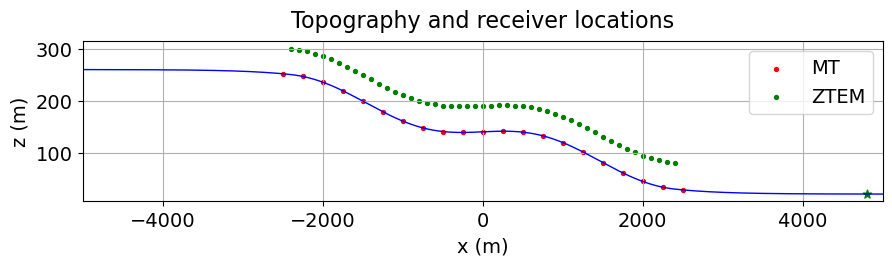

In [5]:
fig = plt.figure(figsize=(10, 2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(locations_x_mt, locations_z_mt, 8, "r")
ax.scatter(locations_x_ztem, locations_z_ztem, 8, "g")
ax.scatter(location_x_base, location_z_base, 40, "g", marker="*")
ax.plot(x_topo, z_topo, color="b", linewidth=1)
ax.set_xlim([x_topo.min(), x_topo.max()])
ax.set_xlabel("x (m)", labelpad=5)
ax.set_ylabel("z (m)", labelpad=5)
ax.grid(True)
ax.set_title("Topography and receiver locations", fontsize=16, pad=10)
ax.legend(['MT', 'ZTEM'])
plt.show(fig)

### Physical Properties

In [6]:
air_conductivity = 1e-8
host_conductivity = 0.01
basement_conductivity = 0.01
target_conductivity = 0.1

## Design a (Tree) Mesh

Meshes are designed using the [discretize](https://discretize.simpeg.xyz/en/main) package. See the [discretize user tutorials](https://discretize.simpeg.xyz/en/main/tutorials/mesh_generation/index.html) to learn more about creating meshes.
Here, the forward simulation is computed for a [tree mesh](xref:discretize#discretize.TreeMesh). Because of the modular nature of SimPEG, you could define a [tensor mesh](xref:discretize#discretize.TensorMesh) instead.

**Standard approach for DC/IP:** The electric potential produced by a current electrode falls off as $r^{-3}$. So smaller cells are needed near the current electrodes to model the fields accurately, and larger cells can be used away from the current electrodes where the fields are smooth. Tree meshes are well-suited for DC (and IP) simulation because the cell size can be increased at specified distances from the current electrodes. For DC resistivity meshing, we advise the following considerations and rules of thumb:

1. Because there are no currents in the air, we do not need to pad upwards. I.e. the top of the mesh corresponds to the top of the topography.
2. We require at least 2-3 cells between each current electrode; with more accurate results being obtained when the minimum cell size is smaller. For a 2.5D problem geometry, we can discretize much finer.
3. To be safe, the padding thickness should be at least 2-3 times the largest electrode spacing. 
4. The increase in cell size at increasing distances from the current electrodes should not happen too abruptly. At each cell size, you should have a layer at least 4 cells thick before increasing the cell size.
5. Finer discretization is required when topography is significant.

**Tutorial mesh:** Here, a minimum cell width of 4 m (or 1/10 the minimum electrode spacing) is used within our survey region. The largest electrode spacing was 400 m, so a the padding was extended at least 1200 m from the survey region. Using the [refine_surface](xref:discretize#discretize.TreeMesh.refine_surface) method, we refine the tree mesh where there is significant topography. And using the [refine_points](xref:discretize#discretize.TreeMesh.refine_points) methods, we refine based on electrodes locations. Visit the [tree mesh](xref:discretize#discretize.TreeMesh) API to see additional refinement methods.

In [7]:
500. / np.sqrt(frequencies_mt.min() * basement_conductivity)

np.float64(5000.0)

In [8]:
500. / np.sqrt(frequencies_mt.max() * host_conductivity)

np.float64(500.0)

In [9]:
500. / np.sqrt(frequencies_mt.max() * target_conductivity)

np.float64(158.11388300841895)

In [10]:
dh = 5.  # base cell width
dom_width_x = 50000.0  # domain width x
dom_width_z = 50000.0  # domain width z
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # num. base cells x
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # num. base cells z

# Define the base mesh with top at z = 0 m.
hx = [(dh, nbcx)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hz], x0="CC", diagonal_balance=True)

# Shift top to maximum topography
mesh.origin = mesh.origin + np.r_[0.0, z_topo.max()]

# Mesh refinement based on topography
mesh.refine_surface(
    topo_2d,
    padding_cells_by_level=[0, 0, 0, 4, 4, 8, 8],
    finalize=False,
)

# Mesh refinement for core region
inds = (topo_2d[:, 0] > -2600.) & (topo_2d[:, 0] < 5000.)
mesh.refine_surface(
    topo_2d[inds, :],
    padding_cells_by_level=[10, 10, 10, 6, 6, 6, 4],
    finalize=False,
)

# Refine around receiver locations
pts = np.vstack(
    [locations_mt, locations_ztem, location_base]
)
mesh.refine_points(
    pts, padding_cells_by_level=[6, 6, 6, 4, 4], finalize=False
)

# mesh.refine(-5)

mesh.finalize()

In [11]:
mesh.n_cells

55867

And we can plot the mesh and electrode locations.

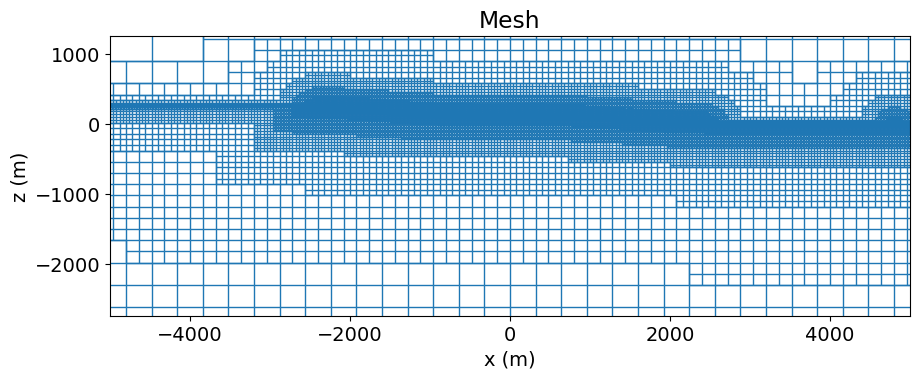

In [12]:
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_axes([0.14, 0.17, 0.8, 0.7])
mesh.plot_grid(ax=ax1, linewidth=1)
ax1.grid(False)
ax1.set_xlim(-5000, 5000)
ax1.set_ylim(np.max(z_topo) - 3000, np.max(z_topo)+1000)
ax1.set_title("Mesh")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

plt.show()

In [13]:
not isinstance(mesh, TreeMesh)

False

## Define the Active Cells

Simulated geophysical data are dependent on the subsurface distribution of physical property values. As a result, the cells lying below the surface topography are commonly referred to as 'active cells'. And air cells, whose physical property values are fixed, are commonly referred to as 'inactive cells'. Here, the discretize [active_from_xyz](xref:discretize#discretize.utils.active_from_xyz) utility function is used to find the indices of the active cells using the mesh and surface topography. The output quantity is a ``bool`` array.

In [14]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_2d)

# number of active cells
n_active = np.sum(active_cells)

## Models and Mappings

In SimPEG, the term 'model' is not necessarily synonymous with the set of physical property values defined on the mesh. For example, the model may be defined as the logarithms of the physical property values, or be the parameters defining a layered Earth geometry. Models in SimPEG are 1D [numpy.ndarray](xref:numpy#numpy.ndarray) whose lengths are
equal to the number of model parameters.

Classes within the [simpeg.maps](xref:simpeg#simpeg.maps.IdentityMap) module are used to define the mapping that connects the model to the physical property values used in the DC resistivity simulation. Sophisticated mappings can be defined by combining multiple mapping objects. But in the simplest case, the mapping is an identity map and the model consists of the conductivity/resistivity values for all mesh cells (including air).

When simulating DC resistivity data, we have the choice of using resistivity or conductivity to define the Earth's electrical properties. Here, we define the model and its associate mapping for two cases:
1. The model consists of the conductivity values for all active cells
2. The model consists of the log-resistivity values for all active cells

### Define the Model

The units for resistivity are $\Omega m$ and the units for conductivity are $S/m$.

In [15]:
# Define conductivity model
conductivity_model = host_conductivity * np.ones(n_active)

ind_basement = mesh.cell_centers[active_cells, -1] < z_topo.max() - 1000.
conductivity_model[ind_basement] = basement_conductivity

ind_target = model_builder.get_indices_block(
    np.r_[-240.0, -640.0], np.r_[240., -240.], mesh.cell_centers[active_cells, :]
)
conductivity_model[ind_target] = target_conductivity

### Mapping from the Model to the Mesh

For our first case, we use the [simpeg.maps.InjectActiveCells](xref:simpeg#simpeg.maps.InjectActiveCells) mapping. This mapping projects quantities defined on the active cells to the entire mesh, and sets a constant value for all inactive cells. **Important:** we set all inactive (air) cells to 1e-8 S/m instead of 0. This is done to ensure that the linear system constructed to solve the PDE for the DC resistivity problem is well-conditioned.

For the second case, we both the [simpeg.maps.InjectActiveCells](xref:simpeg#simpeg.maps.InjectActiveCells) and [simpeg.maps.ExpMap](xref:simpeg#simpeg.maps.ExpMap) mappings; the latter of which takes the natural exponential. **Important:** we set all inactive (air) cells to 1e8 $\Omega m$ instead of $\infty$. Once again, this is done to ensure that the linear system constructed to solve the PDE for the DC resistivity problem is well-conditioned.

In [16]:
# Conductivity map. Model parameters are conductivities for all active cells.
conductivity_map = maps.InjectActiveCells(mesh, active_cells, air_conductivity)

### Plot the Model

To show the geometry of the problem, we plot the conductivity model using the [plot_slice](xref:discretize#discretize.TreeMesh.plot_slice) method.

In [17]:
# Generate a mapping to ignore inactice cells in plot
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

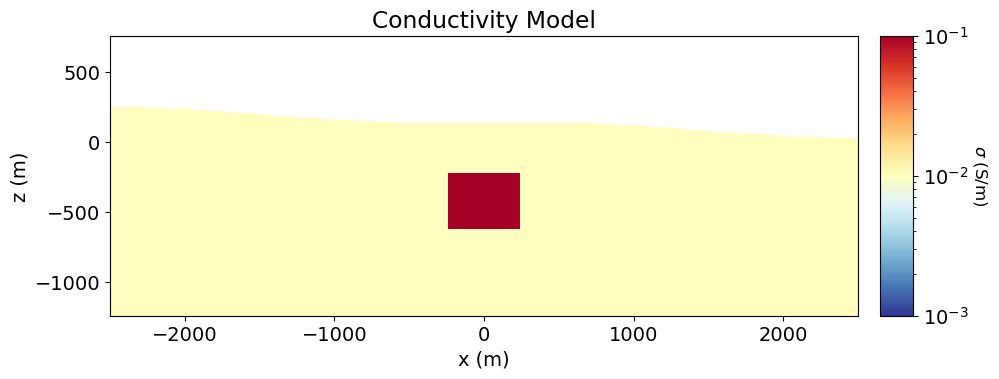

In [18]:
fig = plt.figure(figsize=(11, 4))

norm = LogNorm(vmin=1e-3, vmax=1e-1)

ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
mesh.plot_image(
    plotting_map * conductivity_model,
    ax=ax1,
    grid=False,
    pcolor_opts={"norm": norm, "cmap": mpl.cm.RdYlBu_r},
)
ax1.set_xlim(-2500, 2500)
ax1.set_ylim(np.max(z_topo) - 1500, np.max(z_topo)+500)
ax1.set_title("Conductivity Model")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)

plt.show()

## Shifting to Discrete Topography

In [19]:
try:
    shift_fun = nsem.utils.shift_to_discrete_topography
except:
    from simpeg.electromagnetics.static.utils import drapeTopotoLoc

    def shift_fun(locations, mesh, active_cells, option="top", height=0.0):
    
        locations_shifted = drapeTopotoLoc(
            mesh, locations, active_cells=active_cells, option=option
        )
    
        locations_shifted[:, -1] += height
    
        return locations_shifted


locations_mt_shifted = shift_fun(
    locations_mt, mesh, active_cells, option="top"
)

locations_ztem_shifted = shift_fun(
    locations_ztem, mesh, active_cells, option="top", height=flight_height
)

locations_base_shifted = shift_fun(
    location_base, mesh, active_cells, option="top", height=0.
)
locations_base_shifted = np.tile(locations_base_shifted, (len(locations_x_ztem), 1))

## Defining Survey Objects

To generate a 2D NSEM survey, the user must create and connect three types of objects:

- **receivers:** which define the locations of the NSEM fields being measured and the data type (e.g. impedance, tipper). The recursive 1D solution is used explicitly to compute 1D sounding data corresponding to the $Z_{xy}$ and $Z_{yx}$ impedances. Receivers for simulating these data are defined using the [Impedance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Impedance) class.
- **sources:** which defines the frequencies of the incident planewave source. For a 1D problem geometry, we use the [Planewave](xref:simpeg#simpeg.electromagnetics.static.natural_source.source.Planewave) class.
- **survey:** which uses the [survey](xref:simpeg#simpeg.electromagnetics.natural_source.Survey) class to store and organizes all of the sources and receivers.

**For this tutorial**, we simulate all of the data types corresponding to the $Z_{xy}$ impedance at 11 logarithmically spaced frequencies between 0 Hz and 100 Hz. This includes the real component of the impedance (V/A), the imaginary component (V/A), the apparent resistivity ($\Omega m$) and the phase (deg).

In [20]:
source_list = []  

# Define MT sources and receivers
for freq in frequencies_mt:

    receiver_list = []
    for comp in ['app_res', 'phase']:
        receiver_list.append(
            nsem.receivers.Impedance(
                locations_e=locations_mt_shifted,
                locations_h=locations_mt_shifted,
                orientation='xy',
                component=comp,
            )
        )

    source_list.append(
        nsem.sources.Planewave(
            receiver_list=receiver_list, frequency=freq,
        )
    )

survey_ex = nsem.survey.Survey(source_list)

In [21]:
source_list = []  

# Define ZTEM sources and receivers
for freq in frequencies_ztem:

    receiver_list = []
    for comp in ['real', 'imag']:
        receiver_list.append(
            nsem.receivers.Tipper(
                locations_h=locations_ztem_shifted,
                locations_base=locations_base_shifted,
                orientation='zx',
                component=comp,
            )
        )

    source_list.append(
        nsem.sources.PlanewaveXYPrimary(
            receiver_list=receiver_list, frequency=freq,
        )
    )

survey_ey = nsem.survey.Survey(source_list)

## Define the Forward Simulation

In SimPEG, the physics of the forward simulation is defined by creating an instance of an appropriate simulation class. There are two simulation classes which may be used to simulate 2.5D DC resistivity data:

- [Simulation2DNodel](xref:simpeg#simpeg.electromagnetics.static.resistivity.Simulation2DNodal), which defines the discrete electric potentials on mesh nodes.
- [Simulation2DCellCentered](xref:simpeg#simpeg.electromagnetics.static.resistivity.Simulation2DCellCentered), which defines the discrete electric potentials at cell centers.

For surface DC resistivity data, the nodal formulation is more well-suited and will be used here. The cell-centered formulation works well for simulating borehole DC resistivity data. To fully define the forward simulation, we need to connect the simulation object to:

- the survey
- the mesh
- the mapping from the model to the mesh

This is accomplished by setting each one of the aforementioned items as a property of the simulation object. Here, we define two simulation objects, one where the model defines the subsurface conductivities, and one where the model defines subsurface log-resistivities. When our model is used to define subsurface electric conductivity, the mapping is set using the ``sigmaMap`` keyword argument. However when our model is used to define subsurface electric resistivity, the mapping must be set using the ``rhoMap`` keyword argument

In [22]:
# DC simulation for a conductivity model
simulation_ex = nsem.simulation.Simulation2DElectricField(
    mesh, survey=survey_ex, sigmaMap=conductivity_map
)

# DC simulation for a log-resistivity model
simulation_ey = nsem.simulation.Simulation2DMagneticField(
    mesh, survey=survey_ey, sigmaMap=conductivity_map
)

D:\Documents\Repositories\simpeg\simpeg\base\pde_simulation.py:490: DefaultSolverWarning: Using the default solver: Pardiso. 

If you would like to suppress this notification, add 
warnings.filterwarnings('ignore', simpeg.utils.solver_utils.DefaultSolverWarning)
 to your script.
  return get_default_solver(warn=True)


## Predict DC Resistivity Data

Once any simulation within SimPEG has been properly constructed, simulated data for a given model vector can be computed using the [dpred](xref:simpeg#simpeg.simulation.BaseSimulation.dpred) method. Note that despite the difference in how we defined the models representing the Earth's electrical properties, the data predicted by both simulations is equivalent.

In [23]:
dpred_ex = simulation_ex.dpred(conductivity_model)

In [24]:
dpred_ey = simulation_ey.dpred(conductivity_model)

In [25]:
Zxy = np.reshape(dpred_ex, (len(frequencies_mt), 2, len(locations_x_mt)))
Tzx = np.reshape(dpred_ey, (len(frequencies_ztem), 2, len(locations_x_ztem)))

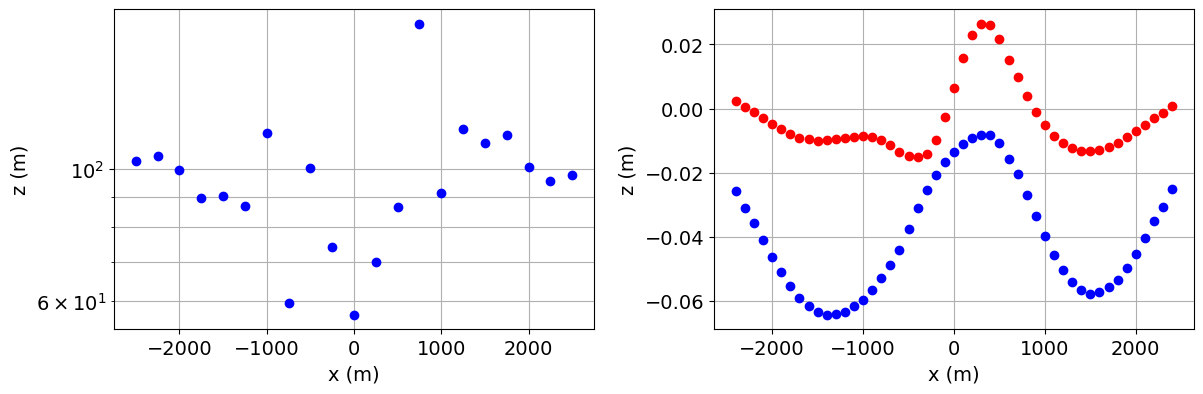

In [26]:
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.4, 0.8])
ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.8])

ax1.semilogy(locations_x_mt, Zxy[5, 0, :], 'bo', linewidth=1)
ax1.set_xlabel("x (m)", labelpad=5)
ax1.set_ylabel("z (m)", labelpad=5)
ax1.grid(which='both')
# ax1.set_title("Topography and receiver locations", fontsize=16, pad=10)
# ax1.legend(['{:.1f} Hz'.format(f) for f in frequencies_mt])

ax2.plot(locations_x_ztem, Tzx[3, 0, :], 'bo', linewidth=1)
ax2.plot(locations_x_ztem, Tzx[3, 1, :], 'ro', linewidth=1)
ax2.set_xlabel("x (m)", labelpad=5)
ax2.set_ylabel("z (m)", labelpad=5)
ax2.grid(which='both')
# ax2.set_title("Topography and receiver locations", fontsize=16, pad=10)
# ax2.legend(['{:.1f} Hz'.format(f) for f in frequencies_mt])

plt.show(fig)

**Optional:** Write DC resistivity data and topography.

In [27]:
if write_output:
    dir_path = os.path.sep.join([".", "fwd_dcr_2d_outputs"]) + os.path.sep
    if not os.path.exists(dir_path):
        os.mkdir(dir_path)

    # Add 5% Gaussian noise to each datum
    rng = np.random.default_rng(seed=225)
    std = 0.05 * np.abs(dpred_con)
    dc_noise = rng.normal(scale=std, size=len(dpred_con))
    dobs = dpred_con + dc_noise

    # Create a survey with the original electrode locations
    # and not the shifted ones
    # Generate source list for DC survey line
    source_list = generate_dcip_sources_line(
        survey_type,
        data_type,
        dimension_type,
        end_locations,
        topo_2d,
        num_rx_per_src,
        station_separation,
    )
    survey_original = dc.survey.Survey(source_list)

    # Write out data at their original electrode locations (not shifted)
    data_obj = data.Data(survey_original, dobs=dobs, standard_deviation=std)
    fname = dir_path + "dc_data.obs"
    write_dcip2d_ubc(fname, data_obj, "volt", "dobs")

    fname = dir_path + "topo_2d.txt"
    np.savetxt(fname, topo_2d, fmt="%.4e")